In [42]:
# Install required libraries
!pip install opencv-python-headless matplotlib numpy Pillow

In [43]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import urllib.request
import os
print("✅ All libraries loaded!")

✅ All libraries loaded!


In [44]:
# Download face detection model files
!wget -q https://raw.githubusercontent.com/opencv/opencv/master/samples/dnn/face_detector/deploy.prototxt -O deploy.prototxt
!wget -q https://github.com/opencv/opencv_3rdparty/raw/dnn_samples_face_detector_20180205_fp16/res10_300x300_ssd_iter_140000_fp16.caffemodel -O face_detector.caffemodel

print("✅ Face detector downloaded!")

✅ Face detector downloaded!


In [45]:
# Load the face detector
face_net = cv2.dnn.readNet("deploy.prototxt", "face_detector.caffemodel")
print("✅ Face detector loaded successfully!")

✅ Face detector loaded successfully!


In [50]:
def detect_mask_enhanced(image_path):
    image = cv2.imread(image_path)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    (h, w) = image.shape[:2]
    blob = cv2.dnn.blobFromImage(image, 1.0, (300, 300),(104.0, 177.0, 123.0))
    face_net.setInput(blob)
    detections = face_net.forward()

    mask_count = 0
    no_mask_count = 0

    for i in range(detections.shape[2]):
        confidence = detections[0, 0, i, 2]
        if confidence > 0.5:
            box = detections[0, 0, i, 3:7] * np.array([w, h, w, h])
            (startX, startY, endX, endY) = box.astype("int")
            face = image[startY:endY, startX:endX]
            if face.size == 0:
                continue

            # Improved: check LOWER half of face only (where mask sits)
            lower_face = face[face.shape[0]//2:, :]
            if lower_face.size == 0:
                continue

            face_hsv = cv2.cvtColor(lower_face, cv2.COLOR_RGB2HSV)
            skin_mask = cv2.inRange(face_hsv, np.array([0,20,70]), np.array([20,255,255]))
            skin_ratio = np.sum(skin_mask > 0) / (lower_face.shape[0] * lower_face.shape[1])

            # If lower face has little skin → mask is covering it
            if skin_ratio < 0.25:
                label, color = "Mask ✓", (0,255,0)
                mask_count += 1
            else:
                label, color = "No Mask ✗", (255,0,0)
                no_mask_count += 1

            cv2.rectangle(image, (startX, startY), (endX, endY), color, 2)
            cv2.putText(image, f"{label} ({confidence*100:.0f}%)",
                       (startX, startY-10), cv2.FONT_HERSHEY_SIMPLEX, 0.6, color, 2)

    cv2.rectangle(image, (0,0), (w, 40), (0,0,0), -1)
    cv2.putText(image, f"Faces: {mask_count+no_mask_count}  |  Mask: {mask_count}  |  No Mask: {no_mask_count}",
               (10, 28), cv2.FONT_HERSHEY_SIMPLEX, 0.7, (255,255,255), 2)

    plt.figure(figsize=(12,8))
    plt.imshow(image)
    plt.axis("off")
    plt.title("Face Mask Detection System", fontsize=16, fontweight='bold')
    plt.show()

    print("\n📊 DETECTION SUMMARY")
    print(f"{'='*30}")
    print(f"Total Faces Detected : {mask_count+no_mask_count}")
    print(f"Wearing Mask         : {mask_count}")
    print(f"Not Wearing Mask     : {no_mask_count}")
    if mask_count+no_mask_count > 0:
        compliance = (mask_count/(mask_count+no_mask_count))*100
        print(f"Mask Compliance Rate : {compliance:.1f}%")

Saving person_nomask.jfif to person_nomask.jfif

🔍 Processing: person_nomask.jfif


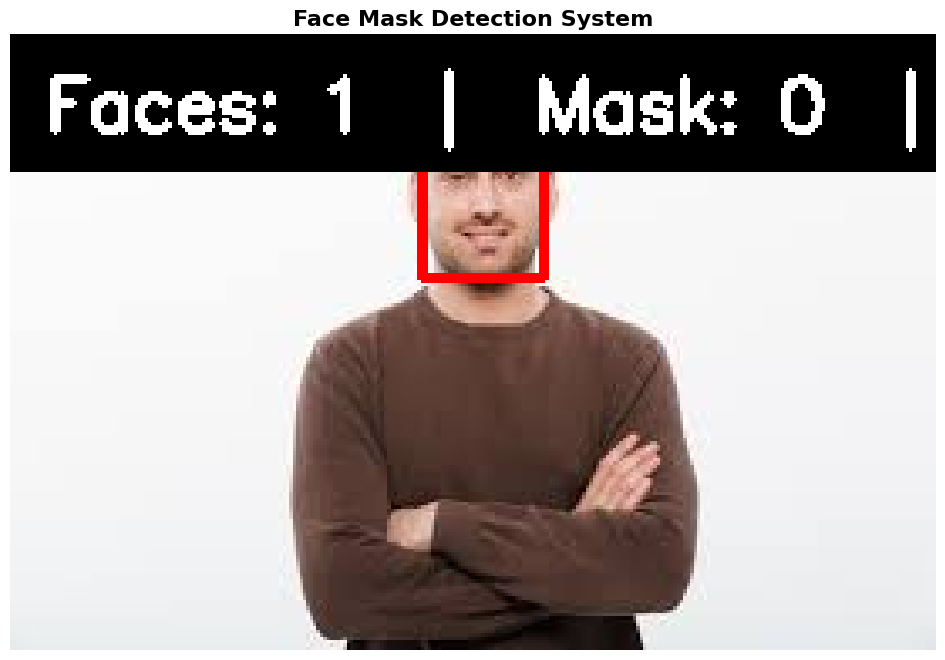


📊 DETECTION SUMMARY
Total Faces Detected : 1
Wearing Mask         : 0
Not Wearing Mask     : 1
Mask Compliance Rate : 0.0%


In [52]:
from google.colab import files
uploaded_multiple = files.upload()

import os
for filename in uploaded_multiple.keys():
    print(f"\n🔍 Processing: {filename}")
    detect_mask_enhanced(filename)

Saving 1person_mask.jfif to 1person_mask.jfif

🔍 Processing: 1person_mask.jfif


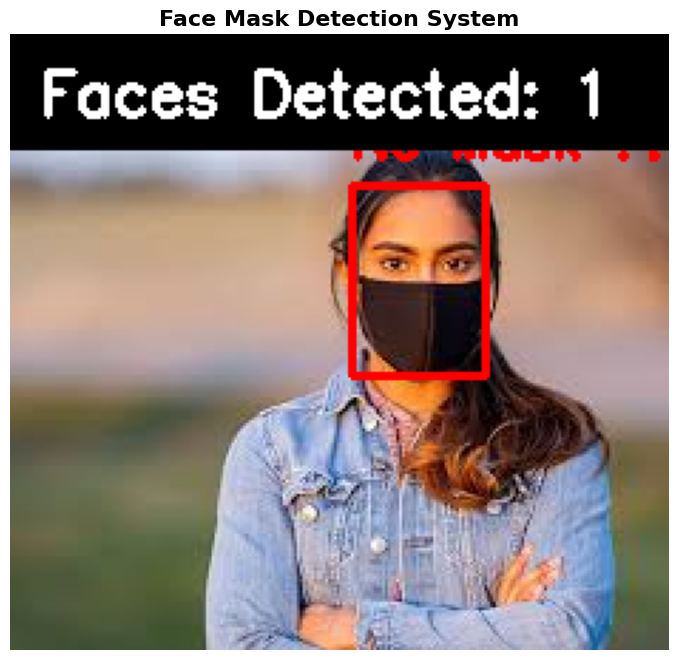


📊 DETECTION SUMMARY
Total Faces Detected : 1
Wearing Mask         : 0
Not Wearing Mask     : 1
Mask Compliance Rate : 0.0%


In [49]:
from google.colab import files
uploaded_multiple = files.upload()

import os
for filename in uploaded_multiple.keys():
    print(f"\n🔍 Processing: {filename}")
    detect_mask_enhanced(filename)